# Image Colorization — 3-Model Inference Notebook

Loads three trained colorizer models and runs inference on a fixed image list.

| # | Model | Architecture | Framework |
|---|-------|-------------|-----------|
| 1 | ConvNeXt Pretrained | ConvNeXt-Base encoder + U-Net decoder | PyTorch |
| 2 | ConvNeXt Finetuned (Bright) | Same arch, finetuned on vivid subset | PyTorch |
| 3 | EfficientNet B7 | EfficientNetB7 encoder + U-Net decoder | PyTorch |

All models use CIELab color space: grayscale L* channel in, predicted a* b* channels out.

---


## Configuration — Edit This Cell

In [1]:
# ==============================================================
# CONFIGURATION — fill in model paths below, then Run All
# ==============================================================

# Model 1: ConvNeXt Pretrained (original)
CONVNEXT_PRETRAINED_PATH = '/kaggle/input/datasets/aurchichowdhury/places-run2-checkpoints/models/convnext_base_colorizer/places_saved_model.pt'

# Model 2: ConvNeXt Finetuned on Bright images
CONVNEXT_FINETUNED_PATH  = '/kaggle/input/datasets/sayaadmuzahidmasfi/finetuned-colorizer/places_bright_epoch01_val0.1172.pt'

# Model 3: EfficientNet B7 — PyTorch .pt file
EFFICIENTNET_MODEL_PATH  = '/kaggle/input/datasets/aurchichowdhury/base-model-07/places_model_07_0.005191.pt'

# ──────────────────────────────────────────────────────────────
# DEMO IMAGE FOLDER — point this to your uploaded dataset folder
# Kaggle will mount your dataset at /kaggle/input/<dataset-slug>/
# Change the path below to match whatever slug you use when uploading.
# All .jpg / .jpeg / .png images inside (including subdirectories)
# will be discovered automatically — no txt file needed.
# ──────────────────────────────────────────────────────────────  # ← CHANGE THIS to your dataset slug

# Optional: cap number of images to process (set None for all)
MAX_IMAGES = None

# Output directory
OUTPUT_DIR = '/kaggle/working/inference_results'

# How many images to show in the comparison grid (keep <= 20 for readability)
VIZ_NUM_IMAGES = 10

print('Configuration loaded.')


Configuration loaded.


## 1. Environment Setup

In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if 'failed' in gpu_info:
    print('No GPU detected. Inference will run on CPU (slower).')
else:
    print(gpu_info)


Sat Apr  4 08:54:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install timm -q
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')


PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import torch
import torch.nn as nn
import timm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch device : {DEVICE}')

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output dir     : {OUTPUT_DIR}')


PyTorch device : cuda
Output dir     : /kaggle/working/inference_results


## 2. Shared Utilities — Color Space Conversion

In [5]:
# Taken verbatim from autocolorization-base-paper-9.ipynb (the training notebook).
# Using float32 BGR input to cv2 directly (no uint8 intermediate round-trip).

def rgb_to_lab_cv2_np(rgb_np):
    """
    Convert a NumPy RGB image (float32, [0,1], H×W×3) to CIELab.
    Returns: L in [0,100], a/b in approximately [-127, 127].
    """
    bgr = rgb_np[..., ::-1]
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2Lab).astype(np.float32)
    return lab


def lab_to_rgb_cv2_np(lab_np):
    """
    Convert a NumPy LAB image (L in [0,100], a/b in [-127,127]) to RGB float32 [0,1].
    """
    lab_cv = np.zeros_like(lab_np)
    lab_cv[..., 0] = lab_np[..., 0] * 255.0 / 100.0
    lab_cv[..., 1] = lab_np[..., 1] + 128.0
    lab_cv[..., 2] = lab_np[..., 2] + 128.0
    lab_cv = np.clip(lab_cv, 0, 255).astype(np.uint8)
    bgr = cv2.cvtColor(lab_cv, cv2.COLOR_LAB2BGR)
    return bgr[..., ::-1].astype(np.float32) / 255.0


def lab_tensors_to_rgb_np(l_tensor, ab_tensor):
    """
    Reconstruct an RGB numpy image from L and ab tensors.
    Taken verbatim from autocolorization-base-paper-9.ipynb.

    l_tensor  : (1, H, W) float32 in [0, 1]
    ab_tensor : (2, H, W) float32 in [-1, 1]
    Returns   : (H, W, 3) float32 numpy array in [0, 1]
    """
    if isinstance(l_tensor, torch.Tensor):
        l_np  = l_tensor.cpu().numpy()
        ab_np = ab_tensor.cpu().numpy()
    else:
        l_np, ab_np = l_tensor, ab_tensor

    l_np  = np.squeeze(l_np)                                        # (H, W)
    ab_np = ab_np.transpose(1, 2, 0) if ab_np.ndim == 3 else ab_np # (H, W, 2)

    # Denormalise — training notebook uses /127 for ab, so undo with *127
    L  = l_np * 100.0
    ab = ab_np * 127.0   # matches the training notebook's ab_ch = lab[...,1:] / 127.0

    lab = np.concatenate([L[..., None], ab], axis=-1).astype(np.float32)
    return lab_to_rgb_cv2_np(lab)


print('Color space utilities defined.')


Color space utilities defined.


In [6]:
def load_image(path, size=224):
    """
    Load an image and return a dict with all representations needed by the three models.

      original_rgb : float32 (H,W,3)     original image in [0,1]
      gray_rgb     : float32 (H,W,3)     grayscale preview in [0,1]
      L_norm       : float32 (H,W,1)     L channel in [0,1]
      ab_gt        : float32 (H,W,2)     ground-truth a*b* in [-1,1]
      L_torch      : torch tensor (1,1,H,W)  ready for all three models

    Color-space convention matches autocolorization-base-paper-9.ipynb:
      L  = lab[..., 0]  / 100.0   → [0, 1]
      ab = lab[..., 1:] / 127.0   → [-1, 1]  (float32 LAB range is [-127, 127])
    """
    img    = Image.open(path).convert('RGB').resize((size, size))
    rgb_np = np.array(img, dtype=np.float32) / 255.0

    lab    = rgb_to_lab_cv2_np(rgb_np)          # L in [0,100], ab in [-127,127]
    L      = lab[..., 0:1]                      # (H,W,1)
    ab     = lab[..., 1:]                       # (H,W,2)

    L_norm  = L  / 100.0                        # [0, 1]
    ab_norm = ab / 127.0                        # [-1, 1]

    # Grayscale preview: set ab to zero and reconstruct
    gray_lab = np.concatenate([L, np.zeros_like(ab)], axis=-1)
    gray_rgb = lab_to_rgb_cv2_np(gray_lab)

    # PyTorch tensor: (1, 1, H, W)
    L_torch = torch.from_numpy(
        L_norm.transpose(2, 0, 1)[np.newaxis]   # (1,1,H,W)
    ).to(DEVICE)

    return dict(
        path=path,
        original_rgb=rgb_np,
        gray_rgb=gray_rgb,
        L_norm=L_norm,
        ab_gt=ab_norm,
        L_torch=L_torch,
    )


def reconstruct_rgb(L_norm_np, ab_pred_np):
    """
    Reconstruct RGB from:
      L_norm_np  : (H,W,1) in [0,1]
      ab_pred_np : (H,W,2) in [-1,1]
    Uses the same denormalisation as lab_tensors_to_rgb_np (ab * 127).
    """
    L  = L_norm_np[..., 0] * 100.0              # (H,W) in [0,100]
    ab = ab_pred_np * 127.0                     # (H,W,2) in [-127,127]
    lab = np.concatenate([L[..., None], ab], axis=-1).astype(np.float32)
    return np.clip(lab_to_rgb_cv2_np(lab), 0, 1)


print('load_image and reconstruct_rgb defined.')


load_image and reconstruct_rgb defined.


## 3. Model Architecture Definitions

### 3a. PyTorch — ConvNeXt-Base Colorizer
Used by both Model 1 and Model 2 (same architecture, different weights).

In [7]:
class ConvNeXtFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            'convnext_base.fb_in22k_ft_in1k',
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3),
        )
        for p in self.backbone.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.backbone(x)


class ConvBNReLU_CNX(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConvNeXtColorizer(nn.Module):
    _MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    _STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    def __init__(self, feature_extractor):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.register_buffer('mean', self._MEAN)
        self.register_buffer('std',  self._STD)
        self.conv_7x7     = ConvBNReLU_CNX(1024, 512, kernel_size=1, padding=0)
        self.conv_14x14   = ConvBNReLU_CNX(512,  256)
        self.conv_28x28   = ConvBNReLU_CNX(256,  128)
        self.conv_56x56   = ConvBNReLU_CNX(128,   64)
        self.conv_112x112 = ConvBNReLU_CNX(64,    64)
        self.conv_224x224 = ConvBNReLU_CNX(64 + 1, 32)
        self.output_conv  = nn.Sequential(nn.Conv2d(32, 2, kernel_size=1), nn.Tanh())
        self.upsample     = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

    def forward(self, x):
        rgb_input = (x.repeat(1, 3, 1, 1) - self.mean) / self.std
        with torch.no_grad():
            s0, s1, s2, s3 = self.feature_extractor(rgb_input)
        t = self.conv_7x7(s3)
        t = self.conv_14x14(self.upsample(t) + s2)
        t = self.conv_28x28(self.upsample(t) + s1)
        t = self.conv_56x56(self.upsample(t) + s0)
        t = self.conv_112x112(self.upsample(t))
        t = self.conv_224x224(torch.cat([self.upsample(t), x], dim=1))
        return self.output_conv(t)  # (B,2,H,W) in [-1,1]


def build_convnext_colorizer():
    fe  = ConvNeXtFeatureExtractor().to(DEVICE)
    col = ConvNeXtColorizer(fe).to(DEVICE)
    col.eval()
    return col


print('ConvNeXt architecture defined.')


ConvNeXt architecture defined.


### 3b. PyTorch — EfficientNet B7 Colorizer

Taken directly from `autocolorization-base-paper-9.ipynb` (Cells 24–25).

Uses forward hooks on `tf_efficientnet_b7` to tap the same five intermediate
activations as the original Keras model:

| Keras layer name | timm hook path | Spatial | Channels |
|---|---|---|---|
| `block2a_expand_activation` | `blocks.1.0.bn1.act` | 112×112 | 192 |
| `block3a_expand_activation` | `blocks.2.0.bn1.act` | 56×56 | 288 |
| `block4a_expand_activation` | `blocks.3.0.bn1.act` | 28×28 | 480 |
| `block6a_expand_activation` | `blocks.5.0.bn1.act` | 14×14 | 1344 |
| `top_activation`            | `bn2.act`            | 7×7   | 2560 |

Decoder channel sizes: 2560→1344→480→288→192→128→64→2, exactly matching the training notebook.


In [8]:
# ── Optional: run this to rediscover hook paths after a timm update ──────────
def print_act_layers(model_name='tf_efficientnet_b7'):
    m = timm.create_model(model_name, pretrained=False)
    for name, mod in m.named_modules():
        if 'act' in name.lower() and ('blocks' in name or name.startswith(('act', 'bn'))):
            print(name, '->', type(mod).__name__)
# print_act_layers()
# ────────────────────────────────────────────────────────────────────────────


class EfficientNetFeatureExtractor(nn.Module):
    """
    Wraps timm's tf_efficientnet_b7 and exposes five intermediate
    feature maps via forward hooks — identical to Cell 24 of the training notebook.
    """
    HOOK_LAYERS = [
        ('blocks.1.0.bn1.act', 'embedding_112x112'),
        ('blocks.2.0.bn1.act', 'embedding_56x56'),
        ('blocks.3.0.bn1.act', 'embedding_28x28'),
        ('blocks.5.0.bn1.act', 'embedding_14x14'),
        ('bn2.act',            'embedding_7x7'),
    ]

    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnet_b7', pretrained=False, features_only=False)
        self.backbone.eval()
        for p in self.backbone.parameters():
            p.requires_grad = False

        self._features = {}
        self._handles  = []
        self._register_hooks()

    def _register_hooks(self):
        named = dict(self.backbone.named_modules())
        for layer_path, key in self.HOOK_LAYERS:
            if layer_path not in named:
                candidates = [k for k in named
                              if 'act' in k.lower()
                              and ('blocks' in k or k.startswith(('act', 'bn')))][:30]
                raise AttributeError(
                    f"\n[EfficientNetFeatureExtractor] Layer '{layer_path}' not found "                    f"in timm {timm.__version__}.\n"                    f"Candidate act-layers:\n  " + "\n  ".join(candidates) +
                    "\n\nUncomment print_act_layers() and update HOOK_LAYERS to match."
                )
            module = named[layer_path]
            k = key
            handle = module.register_forward_hook(
                lambda m, inp, out, k=k: self._features.__setitem__(k, out))
            self._handles.append(handle)

    def forward(self, x):
        """x : (B, 3, 224, 224) float32 in [0, 255]"""
        self._features.clear()
        _ = self.backbone(x)
        return dict(self._features)

    def remove_hooks(self):
        for h in self._handles:
            h.remove()


class ConvBNReLU_EFF(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class EfficientNetColorizer(nn.Module):
    """
    Full colorizer: frozen EfficientNet B7 encoder + trainable decoder.
    Taken verbatim from autocolorization-base-paper-9.ipynb Cell 25.

    Input  : (B, 1, 224, 224)  L* channel in [0, 1]
    Output : (B, 2, 224, 224)  a*b* channels in [-1, 1]

    Decoder:
      7x7   : 1x1 Conv(2560->1344) + BN + ReLU
      14x14 : Add skip(1344), 3x3 Conv(1344->480)  + BN + ReLU
      28x28 : Add skip(480),  3x3 Conv(480->288)   + BN + ReLU
      56x56 : Add skip(288),  3x3 Conv(288->192)   + BN + ReLU
      112x112: Add skip(192), 3x3 Conv(192->128)   + BN + ReLU
      224x224: Cat(128+1L),   3x3 Conv(129->64)    + BN + ReLU
               3x3 Conv(64->2) + Tanh
    """

    def __init__(self, feature_extractor):
        super().__init__()
        self.feature_extractor = feature_extractor

        self.conv_7x7     = ConvBNReLU_EFF(2560, 1344, kernel_size=1, padding=0)
        self.conv_14x14   = ConvBNReLU_EFF(1344, 480)
        self.conv_28x28   = ConvBNReLU_EFF(480,  288)
        self.conv_56x56   = ConvBNReLU_EFF(288,  192)
        self.conv_112x112 = ConvBNReLU_EFF(192,  128)
        self.conv_224x224 = ConvBNReLU_EFF(128 + 1, 64)
        self.output_conv  = nn.Sequential(
            nn.Conv2d(64, 2, kernel_size=3, padding=1),
            nn.Tanh()
        )
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        # x: (B, 1, 224, 224) in [0, 1]
        rgb_input = x.repeat(1, 3, 1, 1) * 255.0   # [0, 255] for EfficientNet

        with torch.no_grad():
            embeddings = self.feature_extractor(rgb_input)

        e_112 = embeddings['embedding_112x112']  # (B, 192,  112, 112)
        e_56  = embeddings['embedding_56x56']    # (B, 288,   56,  56)
        e_28  = embeddings['embedding_28x28']    # (B, 480,   28,  28)
        e_14  = embeddings['embedding_14x14']    # (B, 1344,  14,  14)
        e_7   = embeddings['embedding_7x7']      # (B, 2560,   7,   7)

        t = self.conv_7x7(e_7)                           # (B, 1344,  7,  7)
        t = self.conv_14x14(self.upsample(t) + e_14)    # (B,  480, 14, 14)
        t = self.conv_28x28(self.upsample(t) + e_28)    # (B,  288, 28, 28)
        t = self.conv_56x56(self.upsample(t) + e_56)    # (B,  192, 56, 56)
        t = self.conv_112x112(self.upsample(t) + e_112) # (B,  128, 112,112)
        t = torch.cat([self.upsample(t), x], dim=1)     # (B,  129, 224,224)
        t = self.conv_224x224(t)                         # (B,   64, 224,224)
        return self.output_conv(t)                       # (B,    2, 224,224)


def build_efficientnet_colorizer():
    fe    = EfficientNetFeatureExtractor().to(DEVICE)
    model = EfficientNetColorizer(fe).to(DEVICE)
    model.eval()
    return model


print('EfficientNet B7 architecture defined.')


EfficientNet B7 architecture defined.


## 4. Load All Three Models

In [9]:
def load_convnext_model(checkpoint_path, label):
    """Build the ConvNeXt colorizer and restore weights from a .pt file."""
    print(f'\n[{label}] Loading from: {checkpoint_path}')
    model = build_convnext_colorizer()
    state = torch.load(checkpoint_path, map_location=DEVICE)
    if isinstance(state, dict) and 'generator_state' in state:
        model.load_state_dict(state['generator_state'])
        print('  Unwrapped key: generator_state')
    else:
        model.load_state_dict(state)
        print('  Loaded raw state dict.')
    model.eval()
    print(f'  {label} ready.')
    return model


def load_efficientnet_model(checkpoint_path):
    """
    Build the EfficientNet B7 colorizer and restore weights from a .pt file.

    The training notebook (Cell 35) saves checkpoints as:
        torch.save({
            'epoch': ...,
            'model_state_dict': colorizer.state_dict(),
            'optimizer_state_dict': ...,
            'val_loss': ...,
        }, ckpt_path)

    and saves the best model as a raw state dict:
        torch.save(colorizer.state_dict(), saved_model_path)

    Both formats are handled here.
    """
    print(f'\n[EfficientNet B7] Loading from: {checkpoint_path}')
    model = build_efficientnet_colorizer()
    state = torch.load(checkpoint_path, map_location=DEVICE)

    # Unwrap full checkpoint dict if needed
    if isinstance(state, dict):
        for key in ('model_state_dict', 'generator_state', 'state_dict', 'model'):
            if key in state:
                state = state[key]
                print(f'  Unwrapped checkpoint key: "{key}"')
                break

    model.load_state_dict(state, strict=True)
    model.eval()
    print('  EfficientNet B7 ready.')
    return model


In [10]:
# Model 1: ConvNeXt Pretrained
model_convnext_pretrained = load_convnext_model(CONVNEXT_PRETRAINED_PATH, 'ConvNeXt Pretrained')


[ConvNeXt Pretrained] Loading from: /kaggle/input/datasets/aurchichowdhury/places-run2-checkpoints/models/convnext_base_colorizer/places_saved_model.pt
  Loaded raw state dict.
  ConvNeXt Pretrained ready.


In [11]:
# Model 2: ConvNeXt Finetuned (Bright)
model_convnext_finetuned = load_convnext_model(CONVNEXT_FINETUNED_PATH, 'ConvNeXt Finetuned')


[ConvNeXt Finetuned] Loading from: /kaggle/input/datasets/sayaadmuzahidmasfi/finetuned-colorizer/places_bright_epoch01_val0.1172.pt
  Unwrapped key: generator_state
  ConvNeXt Finetuned ready.


In [12]:
# Model 3: EfficientNet B7
model_efficientnet = load_efficientnet_model(EFFICIENTNET_MODEL_PATH)


[EfficientNet B7] Loading from: /kaggle/input/datasets/aurchichowdhury/base-model-07/places_model_07_0.005191.pt
  Unwrapped checkpoint key: "model_state_dict"
  EfficientNet B7 ready.


## 5. Discover Demo Images from Uploaded Dataset

In [13]:
# ── Auto-discover images from the uploaded demo dataset folder ──────────────
import glob
DEMO_IMAGE_DIR = '/kaggle/input/datasets/aurchichowdhury/colorthis' 

SUPPORTED_EXTS = ('*.jpg', '*.jpeg', '*.JPG', '*.JPEG', '*.png', '*.PNG','*.webp')

if not os.path.isdir(DEMO_IMAGE_DIR):
    raise FileNotFoundError(
        f'Demo image folder not found: {DEMO_IMAGE_DIR}\n'
        'Make sure you have added your image dataset to this notebook\n'
        'and that DEMO_IMAGE_DIR matches the mount path shown in the\n'
        'Data section on the right (e.g. /kaggle/input/<your-dataset-slug>/).'
    )

image_paths = []
for ext in SUPPORTED_EXTS:
    image_paths.extend(glob.glob(os.path.join(DEMO_IMAGE_DIR, '**', ext), recursive=True))

# Remove duplicates that can arise from overlapping glob patterns (e.g. *.jpg vs *.JPG)
image_paths = sorted(set(image_paths))

if not image_paths:
    raise ValueError(
        f'No images found in {DEMO_IMAGE_DIR}\n'
        'Supported formats: JPG, JPEG, PNG'
    )

if MAX_IMAGES is not None:
    image_paths = image_paths[:MAX_IMAGES]

print(f'{len(image_paths)} image(s) found and ready for inference.')
for p in image_paths:
    print(f'  {os.path.basename(p)}')


1 image(s) found and ready for inference.
  91Ir7becmDL._AC_UF8941000_QL80_.jpg


## 6. Run Inference — All Three Models

In [14]:
@torch.no_grad()
def run_model(model, L_torch):
    """Run any PyTorch colorizer. Returns ab (H,W,2) numpy array in [-1,1]."""
    ab = model(L_torch)  # (1, 2, H, W)
    return ab.squeeze(0).permute(1, 2, 0).cpu().numpy()

print('Inference function defined.')


Inference function defined.


In [15]:
results = []

for idx, path in enumerate(image_paths):
    print(f'[{idx+1:03d}/{len(image_paths)}] {os.path.basename(path)}')
    data = load_image(path)

    ab1  = run_model(model_convnext_pretrained, data['L_torch'])
    rgb1 = reconstruct_rgb(data['L_norm'], ab1)

    ab2  = run_model(model_convnext_finetuned, data['L_torch'])
    rgb2 = reconstruct_rgb(data['L_norm'], ab2)

    ab3  = run_model(model_efficientnet, data['L_torch'])
    rgb3 = reconstruct_rgb(data['L_norm'], ab3)

    results.append(dict(
        path=path,
        filename=os.path.basename(path),
        original=data['original_rgb'],
        grayscale=data['gray_rgb'],
        convnext_pre=rgb1,
        convnext_ft=rgb2,
        efficientnet=rgb3,
    ))

print(f'\nInference complete on {len(results)} images.')


[001/1] 91Ir7becmDL._AC_UF8941000_QL80_.jpg

Inference complete on 1 images.


## 7. Save Colorized Outputs to Disk

In [16]:
def save_rgb(img_np, path):
    Image.fromarray((np.clip(img_np, 0, 1) * 255).astype(np.uint8)).save(path)


for r in results:
    stem = Path(r['filename']).stem
    save_rgb(r['original'],     os.path.join(OUTPUT_DIR, f'{stem}_original.png'))
    save_rgb(r['grayscale'],    os.path.join(OUTPUT_DIR, f'{stem}_grayscale.png'))
    save_rgb(r['convnext_pre'], os.path.join(OUTPUT_DIR, f'{stem}_convnext_pretrained.png'))
    save_rgb(r['convnext_ft'],  os.path.join(OUTPUT_DIR, f'{stem}_convnext_finetuned.png'))
    save_rgb(r['efficientnet'], os.path.join(OUTPUT_DIR, f'{stem}_efficientnet.png'))

print(f'All outputs saved to: {OUTPUT_DIR}')


All outputs saved to: /kaggle/working/inference_results


## 8. Visual Comparison — Side-by-Side Grid

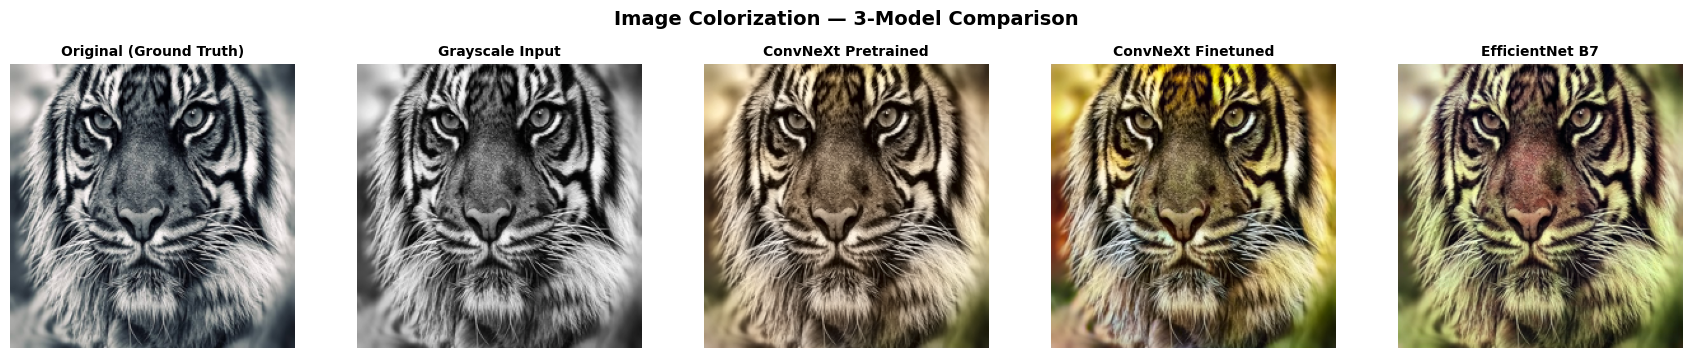

Grid saved to: /kaggle/working/inference_results/comparison_grid.png


In [17]:
viz       = results[:VIZ_NUM_IMAGES]
n_rows    = len(viz)
n_cols    = 5
col_titles = [
    'Original (Ground Truth)',
    'Grayscale Input',
    'ConvNeXt Pretrained',
    'ConvNeXt Finetuned',
    'EfficientNet B7',
]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.5))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row, r in enumerate(viz):
    imgs = [r['original'], r['grayscale'], r['convnext_pre'], r['convnext_ft'], r['efficientnet']]
    for col, (img, title) in enumerate(zip(imgs, col_titles)):
        ax = axes[row, col]
        ax.imshow(np.clip(img, 0, 1))
        ax.axis('off')
        if row == 0:
            ax.set_title(title, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(r['filename'], fontsize=7, rotation=0, labelpad=80, va='center')

plt.suptitle('Image Colorization — 3-Model Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
grid_path = os.path.join(OUTPUT_DIR, 'comparison_grid.png')
plt.savefig(grid_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grid saved to: {grid_path}')


## 9. Colorfulness Score Analysis

Hasler & Susstrunk (2003) colorfulness metric. Higher = more vivid/saturated.

In [18]:
def colorfulness_score(rgb_np):
    img = (np.clip(rgb_np, 0, 1) * 255).astype(np.float32)
    R, G, B = img[..., 0], img[..., 1], img[..., 2]
    rg = R - G
    yb = 0.5 * (R + G) - B
    return (np.sqrt(rg.std()**2 + yb.std()**2)
            + 0.3 * np.sqrt(rg.mean()**2 + yb.mean()**2))


import pandas as pd

rows = []
for r in results:
    rows.append({
        'Image':               r['filename'],
        'Original':            colorfulness_score(r['original']),
        'ConvNeXt Pretrained': colorfulness_score(r['convnext_pre']),
        'ConvNeXt Finetuned':  colorfulness_score(r['convnext_ft']),
        'EfficientNet B7':     colorfulness_score(r['efficientnet']),
    })

df_scores = pd.DataFrame(rows)

print('\nColorfulness Scores (mean across dataset):')
means = df_scores.drop(columns='Image').mean()
for col, val in means.items():
    print(f'  {col:<28}: {val:.2f}')

df_scores



Colorfulness Scores (mean across dataset):
  Original                    : 9.34
  ConvNeXt Pretrained         : 22.89
  ConvNeXt Finetuned          : 48.55
  EfficientNet B7             : 34.37


,Image,Original,ConvNeXt Pretrained,ConvNeXt Finetuned,EfficientNet B7
0,91Ir7becmDL._AC_UF8941000_QL80_.jpg,9.343555,22.893429,48.554413,34.369316


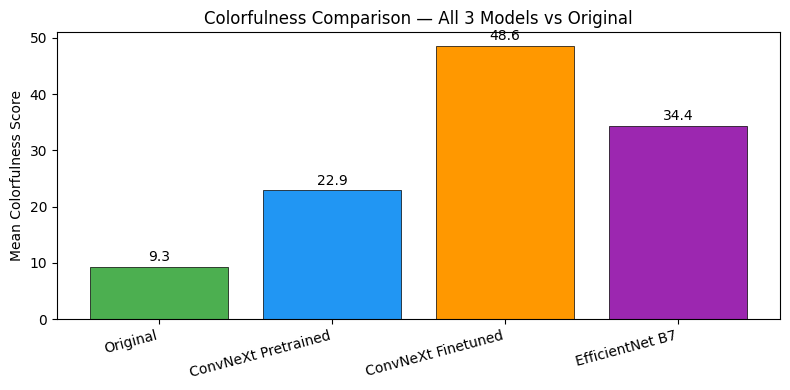

In [19]:
model_names = ['Original', 'ConvNeXt Pretrained', 'ConvNeXt Finetuned', 'EfficientNet B7']
colors      = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
mean_vals   = [means[m] for m in model_names]

plt.figure(figsize=(8, 4))
bars = plt.bar(model_names, mean_vals, color=colors, edgecolor='black', linewidth=0.5)
plt.ylabel('Mean Colorfulness Score')
plt.title('Colorfulness Comparison — All 3 Models vs Original')
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, mean_vals):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'colorfulness_scores.png'), dpi=150)
plt.show()


## Summary

| Model | Architecture | Framework | Weights Source |
|-------|-------------|-----------|----------------|
| ConvNeXt Pretrained | ConvNeXt-Base + U-Net decoder | PyTorch | `places_saved_model.pt` |
| ConvNeXt Finetuned  | Same, finetuned on vivid images | PyTorch | `places_bright_epoch01_val0.1172.pt` |
| EfficientNet B7     | EfficientNetB7 + U-Net decoder | PyTorch | `places_model_07_0.005191.pt` |

All colorized images and the comparison grid have been saved to `OUTPUT_DIR`.
